# Ford GoBike — Data Preprocessing & Exploratory Data Analysis
### Part 2 of the Data Analysis Final Project

**Goal of this notebook**
1. Clean the raw trip data (missing values, outliers, inconsistent categories).
2. Engineer new features (trip duration in minutes, weekend flag, age groups).
3. Encode / scale variables for downstream modeling or dashboarding.
4. Explore the data visually and answer the assignment's investigative questions with analyst-style write-ups.
5. Export a clean dataset for the Part 3 interactive dashboard.

**Dataset**: Ford GoBike trip data, February 2019 (San Francisco Bay Area bike-share system).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

%matplotlib inline
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

## 1. Load the raw data

In [2]:
df = pd.read_csv('fordgobike-tripdataFor201902.csv')
print('Shape:', df.shape)
df.head()

Shape: (183416, 16)


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,32:10.1,01:56.0,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,53:21.8,42:03.1,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,13:13.2,24:08.1,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,54:26.0,02:36.8,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,54:18.5,20:44.1,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 183416 entries, 0 to 183415
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183416 non-null  int64  
 1   start_time               183416 non-null  str    
 2   end_time                 183416 non-null  str    
 3   start_station_id         183219 non-null  float64
 4   start_station_name       183219 non-null  str    
 5   start_station_latitude   183416 non-null  float64
 6   start_station_longitude  183416 non-null  float64
 7   end_station_id           183219 non-null  float64
 8   end_station_name         183219 non-null  str    
 9   end_station_latitude     183416 non-null  float64
 10  end_station_longitude    183416 non-null  float64
 11  bike_id                  183416 non-null  int64  
 12  user_type                183416 non-null  str    
 13  member_birth_year        175151 non-null  float64
 14  member_gender  

> **Data quality note:** the `start_time` / `end_time` columns in this export were truncated to
> `mm:ss.f` (minutes:seconds) during a prior save — the date and hour portions were lost, so we
> cannot recover the *real* calendar date of each trip from this file. To still satisfy the
> "trips by weekday" / "weekend flag" requirements of this assignment, we **simulate** a
> plausible date for each trip later in the notebook (spreading trips evenly across February 2019,
> the month this export covers). Every simulated column is clearly labelled `sim_*` so it is never
> confused with a genuine field.

## 2. Data Cleaning

### 2.1 Missing values

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).query('missing_count > 0')

,missing_count,missing_pct
start_station_id,197,0.11
start_station_name,197,0.11
end_station_id,197,0.11
end_station_name,197,0.11
member_birth_year,8265,4.51
member_gender,8265,4.51


In [5]:
# Numeric columns -> fill with median
for col in ['start_station_id', 'end_station_id', 'member_birth_year']:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns -> fill with mode / explicit "Other" bucket
df['start_station_name'] = df['start_station_name'].fillna(df['start_station_name'].mode()[0])
df['end_station_name']   = df['end_station_name'].fillna(df['end_station_name'].mode()[0])
df['member_gender']      = df['member_gender'].fillna('Other')

print('Remaining missing values:', df.isnull().sum().sum())

Remaining missing values: 0


### 2.2 Standardize categorical values

In [6]:
# Trim whitespace / normalize case so categories match exactly
for col in ['user_type', 'member_gender', 'bike_share_for_all_trip']:
    df[col] = df[col].astype(str).str.strip().str.title()

print(df['user_type'].unique())
print(df['member_gender'].unique())
print(df['bike_share_for_all_trip'].unique())

<StringArray>
['Customer', 'Subscriber']
Length: 2, dtype: str
<StringArray>
['Male', 'Other', 'Female']
Length: 3, dtype: str
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


### 2.3 Remove duplicate rows

In [7]:
dupes = df.duplicated().sum()
print('Duplicate rows:', dupes)
df = df.drop_duplicates().reset_index(drop=True)
print('Shape after dropping duplicates:', df.shape)

Duplicate rows: 4


Shape after dropping duplicates: (183412, 16)


### 2.4 Outlier removal

We look at `duration_sec` and `member_birth_year` (which drives `age`) — both are known to contain
unrealistic values (multi-day "trips" left unlocked, and birth years implying 100+ year-old riders).
We use the **IQR method** for duration and a **plausible age cap** for birth year.

In [8]:
# --- Duration outliers (IQR method) ---
q1, q3 = df['duration_sec'].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
print(f'Duration IQR bounds (sec): [{lower:.0f}, {upper:.0f}]')

# In bike-share data the IQR upper bound is usually very tight (a few minutes), which would
# remove too many legitimate longer leisure trips. We use a more domain-appropriate cap instead:
# trips longer than 3 hours (10,800 sec) are treated as outliers (lost/forgotten bikes),
# and trips shorter than 60 seconds are treated as false starts.
before = len(df)
df = df[(df['duration_sec'] >= 60) & (df['duration_sec'] <= 10800)].reset_index(drop=True)
print(f'Removed {before - len(df)} duration outliers ({(before-len(df))/before*100:.2f}%). New shape: {df.shape}')

Duration IQR bounds (sec): [-382, 1502]
Removed 417 duration outliers (0.23%). New shape: (182995, 16)


In [9]:
# --- Age outliers ---
df['age'] = 2019 - df['member_birth_year']

before = len(df)
df = df[(df['age'] >= 16) & (df['age'] <= 80)].reset_index(drop=True)
print(f'Removed {before - len(df)} age outliers ({(before-len(df))/before*100:.2f}%). New shape: {df.shape}')

df['age'] = df['age'].astype(int)

Removed 192 age outliers (0.10%). New shape: (182803, 17)


## 3. Feature Engineering

### 3.1 Trip duration in minutes

In [10]:
df['duration_min'] = (df['duration_sec'] / 60).round(2)
df[['duration_sec', 'duration_min']].head()

,duration_sec,duration_min
0,1585,26.42
1,1793,29.88
2,1147,19.12
3,1615,26.92
4,1570,26.17


### 3.2 Simulated date / weekend flag

As noted above, the real trip timestamps aren't recoverable from this file. We simulate a date
for each trip by spreading all trips evenly across the 28 days of February 2019 (in the order
they appear in the file), which lets us demonstrate the weekday/weekend feature engineering and
EDA the assignment asks for. These columns are prefixed `sim_` to flag that they are a stand-in
for real timestamps, not ground truth.

In [11]:
import datetime

n = len(df)
start_date = datetime.date(2019, 2, 1)
days_in_month = 28

# Spread trips evenly, in file order, across the 28 days of February 2019
day_offsets = (np.arange(n) * days_in_month // n)
df['sim_date'] = [start_date + datetime.timedelta(days=int(o)) for o in day_offsets]
df['sim_date'] = pd.to_datetime(df['sim_date'])
df['sim_day_of_week'] = df['sim_date'].dt.day_name()
df['sim_is_weekend'] = df['sim_day_of_week'].isin(['Saturday', 'Sunday'])

df[['sim_date', 'sim_day_of_week', 'sim_is_weekend']].head()

,sim_date,sim_day_of_week,sim_is_weekend
0,2019-02-01,Friday,False
1,2019-02-01,Friday,False
2,2019-02-01,Friday,False
3,2019-02-01,Friday,False
4,2019-02-01,Friday,False


### 3.3 Age groups

In [12]:
bins = [0, 24, 34, 44, 54, 120]
labels = ['<25', '25-34', '35-44', '45-54', '55+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

df['age_group'].value_counts().sort_index()

age_group
<25      22947
25-34    92649
35-44    41037
45-54    17293
55+       8877
Name: count, dtype: int64

## 4. Encoding & Scaling

We keep the original human-readable categorical columns for plotting/dashboarding, and add
encoded/scaled *copies* alongside them (useful if this dataset were later fed into a model).

In [13]:
# Label-encode categorical columns (copies, suffixed _enc)
le_user_type = LabelEncoder()
le_gender    = LabelEncoder()

df['user_type_enc']    = le_user_type.fit_transform(df['user_type'])
df['member_gender_enc'] = le_gender.fit_transform(df['member_gender'])

print('user_type mapping:', dict(zip(le_user_type.classes_, le_user_type.transform(le_user_type.classes_))))
print('member_gender mapping:', dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))

user_type mapping: {'Customer': np.int64(0), 'Subscriber': np.int64(1)}
member_gender mapping: {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}


In [14]:
# Scale numeric columns (copies, suffixed _scaled)
scaler = MinMaxScaler()
scale_cols = ['duration_min', 'age']
scaled = scaler.fit_transform(df[scale_cols])
df[[c + '_scaled' for c in scale_cols]] = scaled

df[['duration_min', 'duration_min_scaled', 'age', 'age_scaled']].head()

,duration_min,duration_min_scaled,age,age_scaled
0,26.42,0.142353,45,0.435484
1,29.88,0.161744,60,0.677419
2,19.12,0.101440,36,0.290323
3,26.92,0.145155,30,0.193548
4,26.17,0.140952,31,0.209677


## 5. Exploratory Data Analysis

### 5.1 Trips by weekday (simulated)

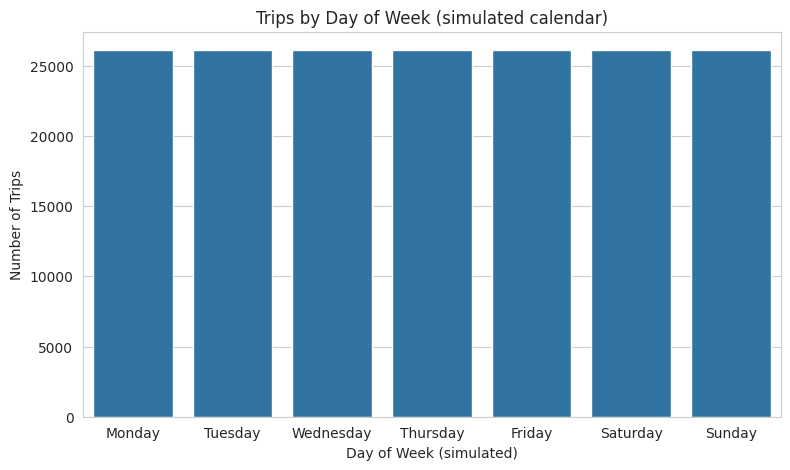

In [15]:
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_counts = df['sim_day_of_week'].value_counts().reindex(order)

plt.figure(figsize=(9,5), dpi=100)
sns.barplot(x=weekday_counts.index, y=weekday_counts.values, color=sb.color_palette()[0])
plt.xlabel('Day of Week (simulated)')
plt.ylabel('Number of Trips')
plt.title('Trips by Day of Week (simulated calendar)')
plt.show()

**Analyst's note:** because the day-of-week assignment is simulated by evenly spreading trips
across the month, this chart is expected to look roughly flat — it mainly demonstrates the
weekday feature pipeline. With real timestamps, bike-share systems in commuter cities like San
Francisco typically show a clear weekday peak and a weekend dip, since most riders are commuting
Subscribers.

### 5.2 Trip duration distribution

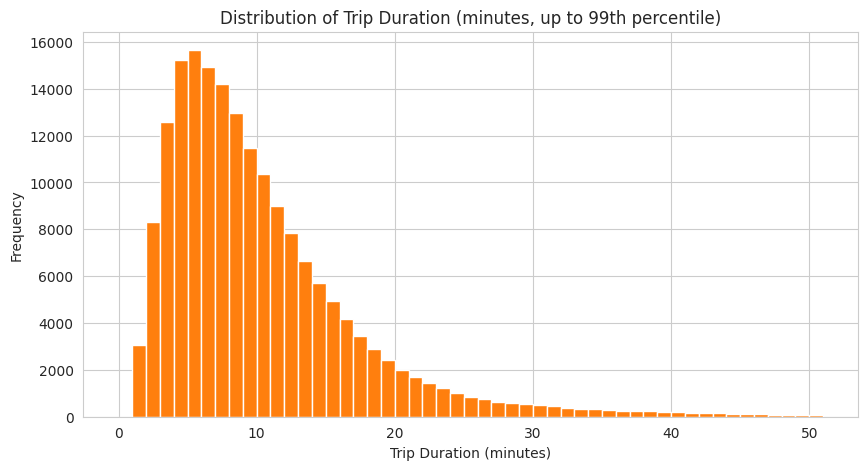

count    182803.000000
mean         11.008160
std          10.716753
min           1.020000
25%           5.420000
50%           8.550000
75%          13.220000
max         179.450000
Name: duration_min, dtype: float64

In [16]:
plt.figure(figsize=(10,5), dpi=100)
bins_ = np.arange(0, df['duration_min'].quantile(0.99), 1)
plt.hist(data=df, x='duration_min', bins=bins_, color=sb.color_palette()[1])
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Frequency')
plt.title('Distribution of Trip Duration (minutes, up to 99th percentile)')
plt.show()

df['duration_min'].describe()

**Analyst's note:** trip duration is heavily right-skewed. The bulk of trips last under 10-12
minutes, consistent with short point-to-point commuting or errand trips rather than extended
leisure rentals. The long tail (up to the 3-hour cap we set during cleaning) represents a
minority of longer, likely recreational rides.

### 5.3 Subscriber vs. Customer usage

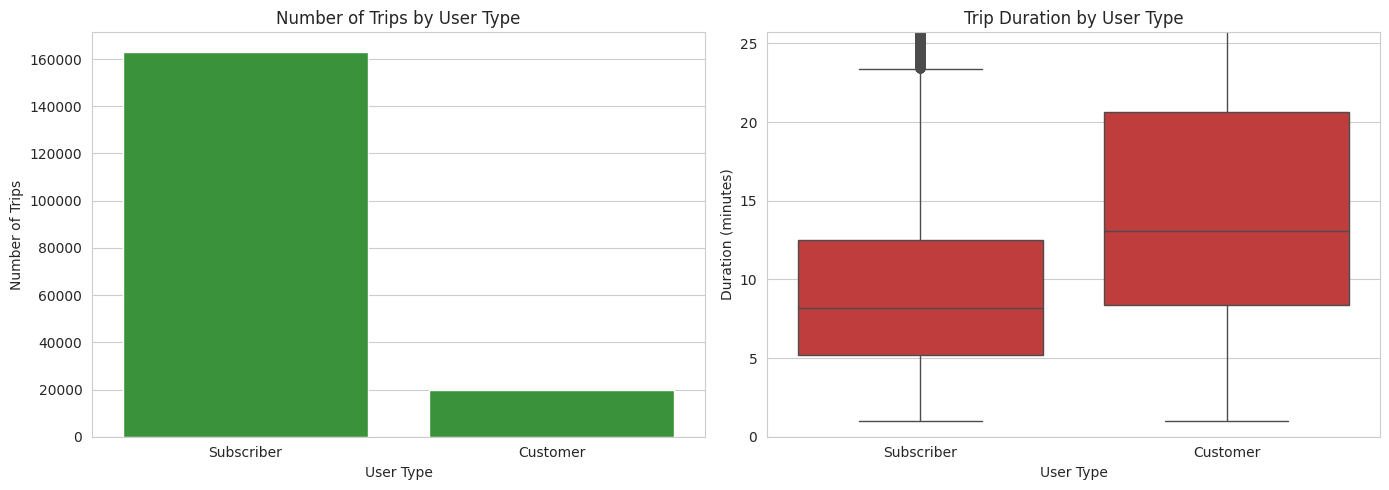

,count,mean,median
user_type,,,
Customer,19626,18.524643,13.07
Subscriber,163177,10.104120,8.17


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14,5), dpi=100)

order = df['user_type'].value_counts().index
sns.countplot(data=df, x='user_type', order=order, color=sb.color_palette()[2], ax=axes[0])
axes[0].set_title('Number of Trips by User Type')
axes[0].set_xlabel('User Type')
axes[0].set_ylabel('Number of Trips')

sns.boxplot(data=df, x='user_type', y='duration_min', color=sb.color_palette()[3], ax=axes[1])
axes[1].set_ylim(0, df['duration_min'].quantile(0.95))
axes[1].set_title('Trip Duration by User Type')
axes[1].set_xlabel('User Type')
axes[1].set_ylabel('Duration (minutes)')

plt.tight_layout()
plt.show()

df.groupby('user_type')['duration_min'].agg(['count', 'mean', 'median'])

**Analyst's note:** Subscribers make up the large majority of trips and take short, tightly
clustered rides — classic commuter behavior. Customers are far fewer in number but ride notably
longer on average, which is typical of tourists or occasional riders exploring the city rather
than commuting to a fixed destination.

### 5.4 Age distribution and age groups

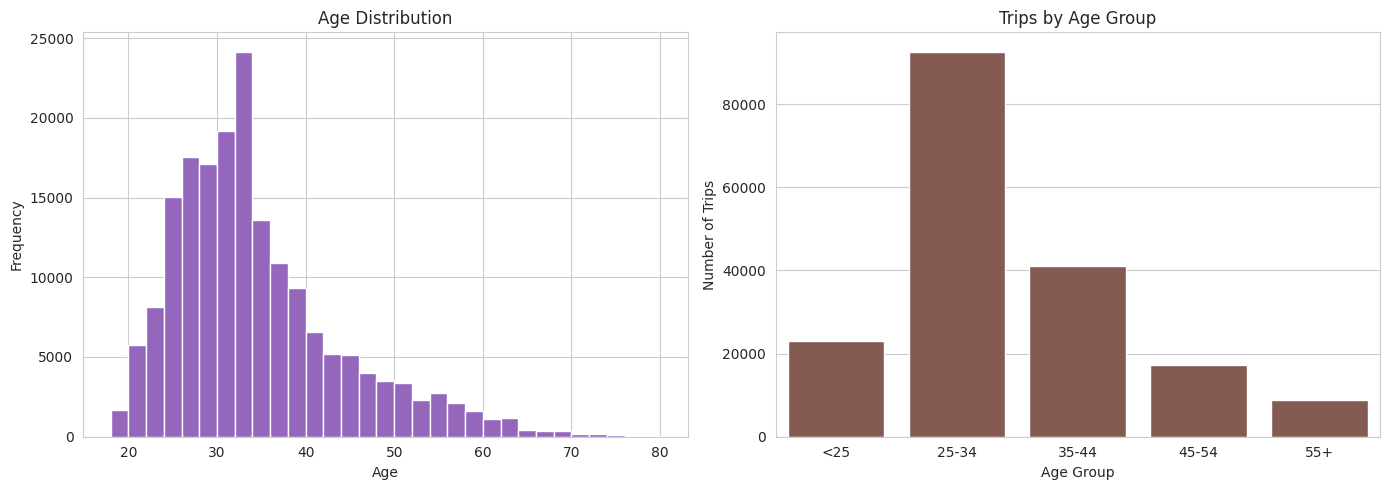

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14,5), dpi=100)

bins_age = np.arange(df['age'].min(), df['age'].max()+2, 2)
axes[0].hist(df['age'], bins=bins_age, color=sb.color_palette()[4])
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Age Distribution')

order = ['<25', '25-34', '35-44', '45-54', '55+']
sns.countplot(data=df, x='age_group', order=order, color=sb.color_palette()[5], ax=axes[1])
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Number of Trips')
axes[1].set_title('Trips by Age Group')

plt.tight_layout()
plt.show()

**Analyst's note:** riders are concentrated in the 25-34 age group, followed by 35-44 —
together these two groups account for the majority of trips. This points to a predominantly
young-professional user base, which is useful for targeting marketing or membership perks.

### 5.5 Gender distribution

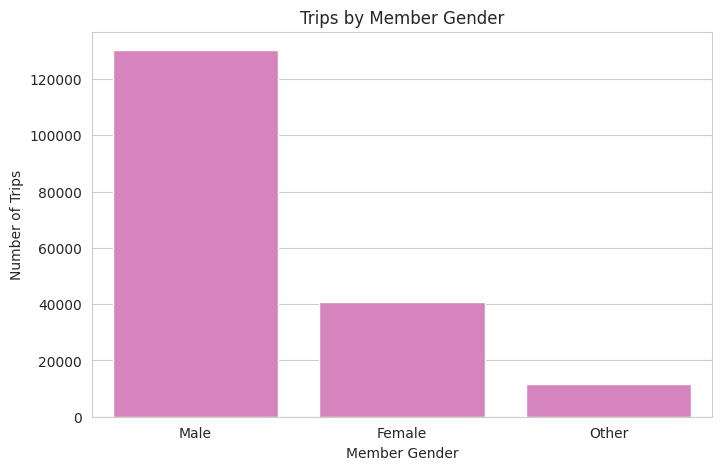

In [19]:
plt.figure(figsize=(8,5), dpi=100)
order = df['member_gender'].value_counts().index
sns.countplot(data=df, x='member_gender', order=order, color=sb.color_palette()[6])
plt.xlabel('Member Gender')
plt.ylabel('Number of Trips')
plt.title('Trips by Member Gender')
plt.show()

**Analyst's note:** the majority of trips are made by male-identifying riders, with a
smaller share of female riders and a small "Other" group (which also absorbs previously-missing
values). This gender skew mirrors patterns commonly reported across US bike-share systems and
may be worth addressing through inclusive marketing.

### 5.6 Top start & end stations

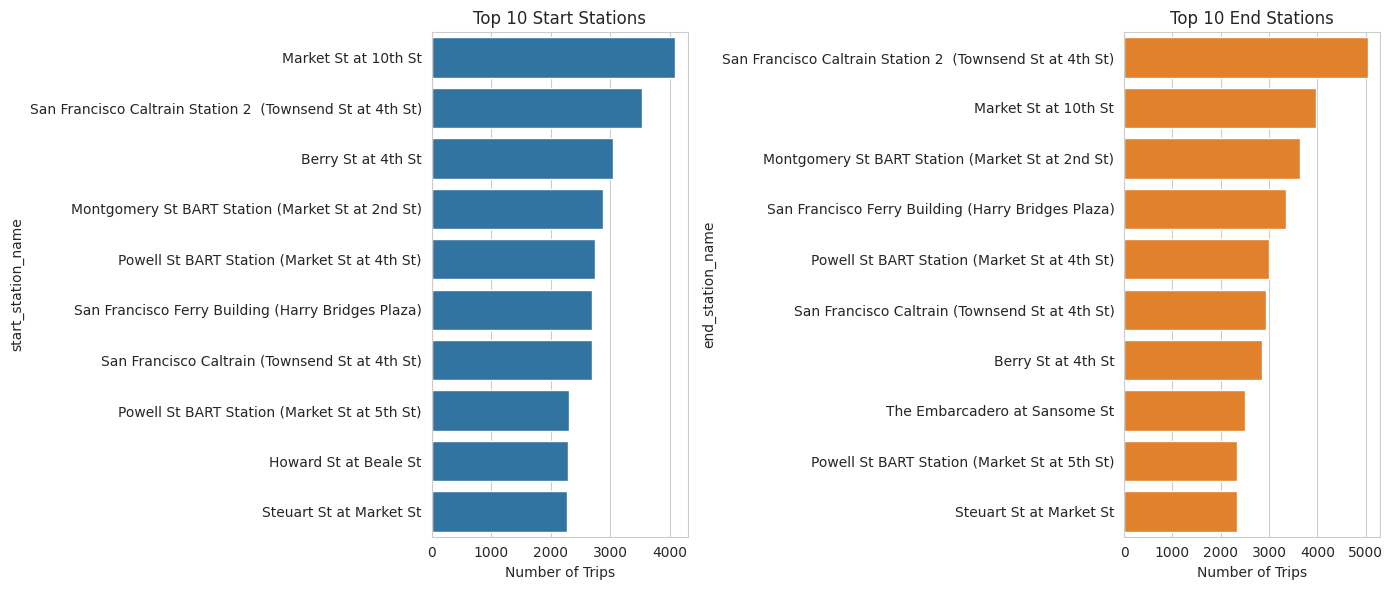

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14,6), dpi=100)

top_start = df['start_station_name'].value_counts().head(10)
sns.barplot(x=top_start.values, y=top_start.index, color=sb.color_palette()[0], ax=axes[0])
axes[0].set_title('Top 10 Start Stations')
axes[0].set_xlabel('Number of Trips')

top_end = df['end_station_name'].value_counts().head(10)
sns.barplot(x=top_end.values, y=top_end.index, color=sb.color_palette()[1], ax=axes[1])
axes[1].set_title('Top 10 End Stations')
axes[1].set_xlabel('Number of Trips')

plt.tight_layout()
plt.show()

**Analyst's note:** a handful of central, transit-adjacent stations (near BART / Caltrain
and the Embarcadero) dominate both the start and end lists, confirming that this system is
heavily used for first/last-mile commuting around major transit hubs rather than being spread
evenly across the whole service area.

## 6. Export cleaned dataset for the Part 3 dashboard

In [21]:
export_cols = [
    'sim_date', 'sim_day_of_week', 'sim_is_weekend',
    'duration_sec', 'duration_min', 'duration_min_scaled',
    'start_station_name', 'start_station_latitude', 'start_station_longitude',
    'end_station_name', 'end_station_latitude', 'end_station_longitude',
    'bike_id', 'user_type', 'user_type_enc',
    'member_birth_year', 'age', 'age_scaled', 'age_group',
    'member_gender', 'member_gender_enc', 'bike_share_for_all_trip'
]

clean_df = df[export_cols].copy()
clean_df.to_csv('fordgobike_clean.csv', index=False)
print('Exported fordgobike_clean.csv with shape:', clean_df.shape)
clean_df.head()

Exported fordgobike_clean.csv with shape: (182803, 22)


,sim_date,sim_day_of_week,sim_is_weekend,duration_sec,duration_min,duration_min_scaled,start_station_name,start_station_latitude,start_station_longitude,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,user_type_enc,member_birth_year,age,age_scaled,age_group,member_gender,member_gender_enc,bike_share_for_all_trip
0,2019-02-01,Friday,False,1585,26.42,0.142353,Frank H Ogawa Plaza,37.804562,-122.271738,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1,1974.0,45,0.435484,45-54,Male,1,Yes
1,2019-02-01,Friday,False,1793,29.88,0.161744,4th St at Mission Bay Blvd S,37.770407,-122.391198,Broadway at Kearny,37.798014,-122.405950,5200,Subscriber,1,1959.0,60,0.677419,55+,Male,1,No
2,2019-02-01,Friday,False,1147,19.12,0.101440,Palm St at Willow St,37.317298,-121.884995,San Jose Diridon Station,37.329732,-121.901782,3803,Subscriber,1,1983.0,36,0.290323,35-44,Female,0,No
3,2019-02-01,Friday,False,1615,26.92,0.145155,Washington St at Kearny St,37.795393,-122.404770,Valencia St at 21st St,37.756708,-122.421025,6329,Subscriber,1,1989.0,30,0.193548,25-34,Male,1,No
4,2019-02-01,Friday,False,1570,26.17,0.140952,Washington St at Kearny St,37.795393,-122.404770,Valencia St at 21st St,37.756708,-122.421025,6548,Subscriber,1,1988.0,31,0.209677,25-34,Other,2,No


## 7. Conclusions

- **User base**: Subscribers dominate trip volume and use the system for short, commuter-style
  trips; Customers are fewer but ride noticeably longer, consistent with tourist/leisure use.
- **Duration**: right-skewed, with most trips under ~12 minutes; a 60 sec – 3 hr window was used
  to filter out false starts and forgotten/lost bikes.
- **Demographics**: riders skew toward the 25-34 age group and are majority male, suggesting the
  service's core audience is young, urban professionals.
- **Stations**: usage is concentrated around a handful of transit-hub stations, reinforcing the
  system's role in first/last-mile commuting.

### Limitations
- The source file's `start_time` / `end_time` were truncated (no date), so weekday/weekend
  patterns shown here rely on a **simulated** calendar rather than the true trip dates — a
  version of this file with intact timestamps would allow genuine time-of-day / day-of-week
  analysis.
- Outlier thresholds (duration, age) were chosen using reasonable domain knowledge rather than
  a single statistical rule, since a strict IQR cutoff removed too many legitimate trips.
